Why Standard Attention Fails on Long Texts?

Standard Transformer attention calculates how every single token relates to every other token in a sequence. If your sequence has $n$ tokens, every token checks $n$ other positions, producing an $O(n^2)$ computational and memory complexity. 512 tokens: $\approx 260,000$ attention scores per layer.4,096 tokens: Over 16 million attention scores per layer.Because GPU memory must store these massive $n \times n$ attention matrices for backpropagation, standard Transformers quickly run out of memory (OOM) on long documents.

The Longformer Solution: Combining Local and Global AttentionLongformer reduces this quadratic complexity down to $O(n)$ (linear time) by splitting the sequence into two categories of tokens:
- Local Tokens ($L$): The vast majority of tokens ($\approx n$). They only attend to their immediate neighbors within a small local window ($w$).
- Global Tokens ($G$): A tiny handful of critical tokens ($\le 10$, e.g., [CLS] or question tokens) that attend to the entire sequence—and that every local token can attend back to.

Step-by-Step Mathematical Formulation

1. Sliding Window (Local) AttentionInstead of projecting key ($K$) and value ($V$) matrices over the full length $n$, position $i$ only looks at a localized context slice spanning from $[i - w/2]$ to $[i + w/2]$.$$\text{Attention}_i = \text{softmax}\left(\frac{Q_i K_{[i - w/2 : i + w/2]}^\top}{\sqrt{d_k}}\right) V_{[i - w/2 : i + w/2]}$$

Equation Breakdown:

$Q_i = x_i W_Q$: The Query vector for token $i$, calculated by passing the token embedding $x_i$ through a learned projection matrix $W_Q$. It represents what token $i$ is searching for.

$K_{[i - w/2 : i + w/2]}$: The Key matrix restricted only to the local window of size $w$. Shape: $(w, d_k)$. It represents what nearby tokens offer.

$V_{[i - w/2 : i + w/2]}$: The Value matrix for the same window of size $w$. Shape: $(w, d_k)$. It contains the actual contextual information to be extracted.

$\sqrt{d_k}$: A scaling factor based on the query/key dimension $d_k$ (typically 64). It prevents high-dimensional dot products from exploding, which would otherwise push the softmax function into regions with near-zero gradients.

$\text{softmax}(\dots)$: Converts the raw dot-product similarity scores into a probability distribution of size $w$ that sums to 1.

$\times V_{\dots}$: Computes a weighted sum over the local Value vectors based on the softmax probabilities.

Key takeaway: Computing dot products against $w$ keys instead of $n$ keys drops the cost per token from $O(n)$ down to $O(w)$. Across all $n$ tokens, this stage costs $O(nw)$.

2. Global AttentionLocal sliding windows capture local syntax, but distant tokens cannot easily talk to each other. Global tokens fix this by acting as relay stations.

For a designated global token $g \in G$:
$$\text{Attention}_g = \text{softmax}\left(\frac{Q_g K^\top}{\sqrt{d_k}}\right) V$$

Equation Breakdown:

$Q_g = x_g W_{Q_g}$: The Query vector for a global token $g$.

$W_{Q_g}, W_{K_g}, W_{V_g}$: Separate learned projection matrices used specifically for global tokens. Global tokens ask broad, document-level questions ("What is the main topic?"), whereas local tokens ask local syntactic questions ("Which verb modifies this noun?"). Using separate projection parameters prevents the two tasks from interfering with each other during optimization.

$K$ and $V$: The Key and Value matrices spanning the entire sequence of length $n$. Shape: $(n, d_k)$.

Key takeaway: Because there are very few global tokens ($\vert{}G\vert{} \le 10$), performing full $O(n)$ attention for just those few tokens costs $O(\vert{}G\vert{} \cdot n)$, which remains linear.

In [2]:
!pip install numpy

  Using cached numpy-2.5.3-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.5.3-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)


In [ ]:
import numpy as np

def create_longformer_attention_mask(seq_len, window_size, global_positions):
    """
    Create a Longformer-style attention mask.

    Args:
        seq_len: Total sequence length
        window_size: Size of sliding window (must be even)
        global_positions: List of positions that have global attention

    Returns:
        Attention mask of shape (seq_len, seq_len)
    """

    mask = np.zeros((seq_len, seq_len))
    half_window = window_size // 2 

    # implement sliding window for all position
    for i in range(seq_len):
        start = max(0, i - half_window)
        end = min(seq_len, i + half_window + 1)
    mask[i, start:end] = 1 

    # Add global attention: global tokens attend to all, all attend to global
    for g in global_positions:
        mask[g, :] = 1  # Global token attends to all
        mask[:, g] = 1  # All tokens attend to global token

    return mask



In [9]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.3.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 5.0 MB/s  0:00:02 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 5.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.3 MB/s  0:00:00 eta 0:00:01
Using cached pillow-12.3.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (6.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


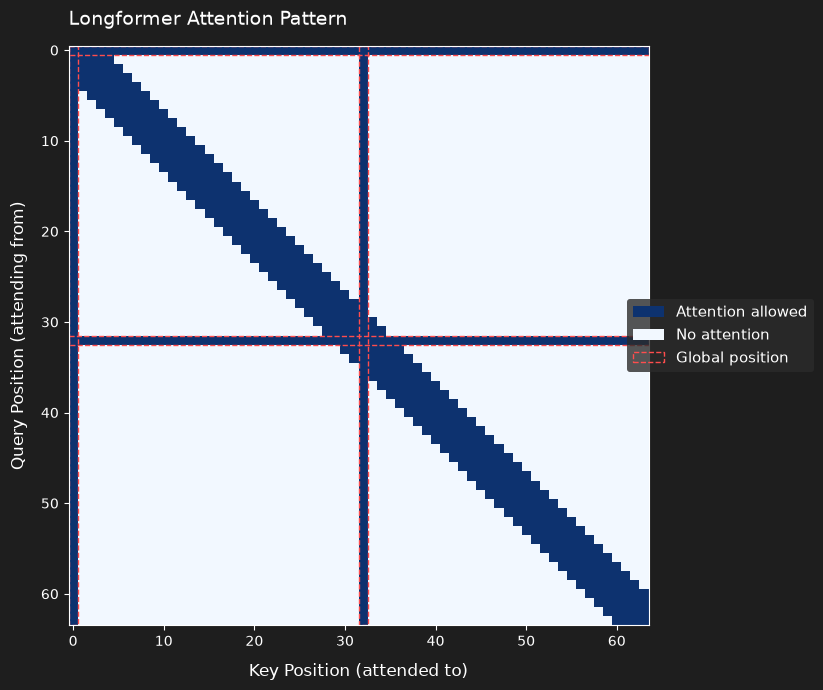

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch, Rectangle

# 1. Function to create the Longformer mask (with fixed indentation)
def create_longformer_attention_mask(seq_len, window_size, global_positions):
    """
    Create a Longformer-style attention mask.

    Args:
        seq_len: Total sequence length
        window_size: Size of sliding window (must be even)
        global_positions: List of positions that have global attention

    Returns:
        Attention mask of shape (seq_len, seq_len)
    """
    mask = np.zeros((seq_len, seq_len))
    half_window = window_size // 2 

    # Implement sliding window for all positions
    for i in range(seq_len):
        start = max(0, i - half_window)
        end = min(seq_len, i + half_window + 1)
        mask[i, start:end] = 1 

    # Add global attention: global tokens attend to all, all attend to global
    for g in global_positions:
        mask[g, :] = 1  # Global token attends to all
        mask[:, g] = 1  # All tokens attend to global token

    return mask

# 2. Parameters (matching the plot: seq_len ~64, window_size ~6, global positions at 0 and 32)
seq_len = 64
window_size = 6
global_positions = [0, 32]

mask = create_longformer_attention_mask(seq_len, window_size, global_positions)

# 3. Styling setup to match the dark theme in the image
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(8, 7), facecolor='#1e1e1e')
ax.set_facecolor('#1e1e1e')

# Custom Colormap: 0 = Light Ice Blue/White, 1 = Deep Navy Blue
cmap = ListedColormap(['#f2f8ff', '#0d326f'])

# Render heatmap
im = ax.imshow(mask, cmap=cmap, interpolation='nearest', origin='upper')

# 4. Draw red dashed outlines around global positions
for g in global_positions:
    # Row highlight
    rect_row = Rectangle((-0.5, g - 0.5), seq_len, 1, 
                         linewidth=1, edgecolor='#ff4d4d', facecolor='none', linestyle='--')
    # Column highlight
    rect_col = Rectangle((g - 0.5, -0.5), 1, seq_len, 
                         linewidth=1, edgecolor='#ff4d4d', facecolor='none', linestyle='--')
    ax.add_patch(rect_row)
    ax.add_patch(rect_col)

# 5. Labels, Limits, and Titles
ax.set_title("Longformer Attention Pattern", fontsize=14, pad=15, loc='left', color='white')
ax.set_xlabel("Key Position (attended to)", fontsize=12, labelpad=10, color='white')
ax.set_ylabel("Query Position (attending from)", fontsize=12, labelpad=10, color='white')

ax.set_xlim(-0.5, seq_len - 0.5)
ax.set_ylim(seq_len - 0.5, -0.5)

# Adjust tick styling
ax.tick_params(colors='white', labelsize=10)

# 6. Build Legend
legend_elements = [
    Patch(facecolor='#0d326f', label='Attention allowed'),
    Patch(facecolor='#f2f8ff', label='No attention'),
    Rectangle((0, 0), 1, 1, fill=False, edgecolor='#ff4d4d', linestyle='--', label='Global position')
]

legend = ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0.95, 0.5),
                   facecolor='#2b2b2b', edgecolor='none', labelcolor='white', fontsize=11)

plt.tight_layout()
plt.show()

When using Longformer, choosing the Window Size ($w$) is a balancing act between speed/memory and how fast information spreads across layers.

The graph shows a fixed document length of 4,096 tokens and compares two key metrics as you change the window size:

1. Attention Density (Blue Solid Line - Left Y-Axis): How much memory and compute you use per layer. Higher means heavier on GPU memory.

2. Layers Needed for Full Coverage (Red Dashed Line - Right Y-Axis): How many transformer layers you need before a token at the very beginning of the document can "talk" to a token at the very end purely through local sliding windows.

Core Concepts:

- Attention Density (The Memory Cost)What it means: The percentage of the full $4096 \times 4096$ attention matrix that you are actually computing.

- Math: $\text{Density} = \frac{\text{Window Size}}{\text{Sequence Length}} = \frac{w}{4096}$

- Trend: As you make the window size bigger, the blue line goes up. You look at more tokens at once, which costs more GPU memory and compute time.   

2. Receptive Field Expansion (The "Game of Telephone")

In a single layer, a token can only see $w$ neighbors around it. But in the next layer, those neighbors pass along information from their neighbors.

Information spreads across layers like a snowball:$$\text{Receptive Field} = \text{Number of Layers} \times \text{Window Size}$$

To cover a 4,096-token document purely using local windows:$$\text{Layers Needed} = \frac{\text{Sequence Length}}{\text{Window Size}} = \frac{4096}{w}$$

Trend: As you make the window size bigger, the red line goes down. Larger windows let information reach the whole document in fewer layers. 


In [11]:
def compute_attention_density(seq_len, window_size, num_global):
    """Compute the fraction of non-zero attention weights."""
    # Sliding window: each of n tokens attends to w tokens
    sliding_window_entries = seq_len * window_size

    # Global attention: each global token adds (n-1) new connections
    # (excluding the window entries we already counted)
    global_entries = num_global * (seq_len - window_size) * 2

    # Total possible entries
    total_possible = seq_len**2

    # Approximate density (some overlap, but gives the right idea)
    density = min(
        1.0, (sliding_window_entries + global_entries) / total_possible
    )
    return density


# Compare densities at different sequence lengths
seq_lengths = [512, 1024, 2048, 4096, 8192, 16384]
window_size = 512
num_global = 2

densities = [
    compute_attention_density(n, window_size, num_global) for n in seq_lengths
]
full_attention_memory = [n**2 for n in seq_lengths]
longformer_memory = [n * (window_size + 2 * num_global) for n in seq_lengths]

Saved test_plot.png


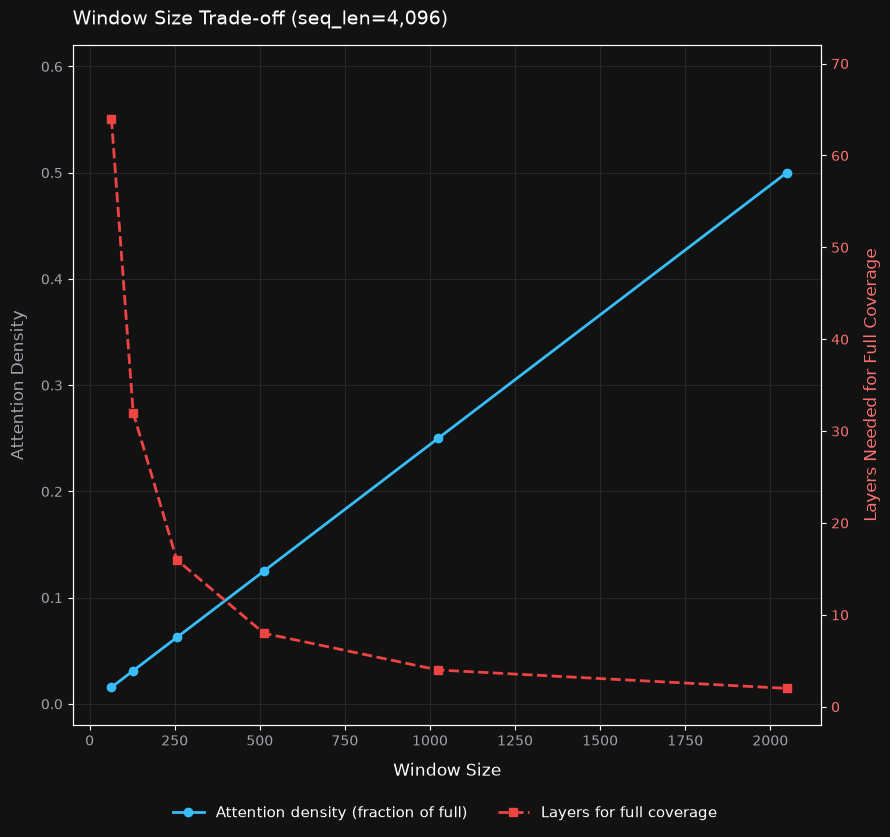

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Data setup
seq_len = 4096
window_sizes = np.array([64, 128, 256, 512, 1024, 2048])
densities = window_sizes / seq_len
layers = seq_len / window_sizes

# Dark style
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(9, 8), facecolor='#121212')
ax1.set_facecolor('#121212')

# Colors
blue_color = '#38bdf8'
red_color = '#ef4444'

# Plot 1: Attention Density (Left Axis)
line1, = ax1.plot(window_sizes, densities, color=blue_color, marker='o', linewidth=2, label='Attention density (fraction of full)')
ax1.set_xlabel('Window Size', color='white', fontsize=12, labelpad=10)
ax1.set_ylabel('Attention Density', color='#a1a1aa', fontsize=12, labelpad=10)
ax1.tick_params(axis='y', labelcolor='#a1a1aa')
ax1.tick_params(axis='x', labelcolor='#a1a1aa')
ax1.set_ylim(-0.02, 0.62)
ax1.set_xlim(-50, 2150)
ax1.grid(True, color='#27272a', linestyle='-', linewidth=0.8)

# Plot 2: Layers Needed for Full Coverage (Right Axis)
ax2 = ax1.twinx()
line2, = ax2.plot(window_sizes, layers, color=red_color, marker='s', linestyle='--', linewidth=2, label='Layers for full coverage')
ax2.set_ylabel('Layers Needed for Full Coverage', color='#f87171', fontsize=12, labelpad=10)
ax2.tick_params(axis='y', labelcolor='#f87171')
ax2.set_ylim(-2, 72)

# Title
plt.title('Window Size Trade-off (seq_len=4,096)', color='white', fontsize=14, pad=15, loc='left')

# Combined Legend at bottom
lines = [line1, line2]
labels = [l.get_label() for l in lines]
fig.legend(lines, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False, labelcolor='white', fontsize=11)

plt.tight_layout()
plt.savefig('test_plot.png', bbox_inches='tight', dpi=150)
print("Saved test_plot.png")

In [15]:
import torch


ModuleNotFoundError: No module named 'torch'